# 06 — Whale Optimization Algorithm (WOA) Feature Selection

**Goal:** use WOA to search for the feature subset that maximizes classification
performance while minimizing the number of features used. WOA mimics the bubble-net hunting strategy of humpback whales, balancing exploration (random search) with exploitation (encircling prey / spiral attack) as iterations progress.

This notebook follows the exact same pipeline as every other optimizer notebook in
this project (GA / PSO / GWO / WOA) — only the optimizer differs — so results are
directly comparable in `07_Comparison.ipynb`.

**Pipeline:**

```
Initialize population (candidate feature masks)
        |
        v
  Evaluate fitness (via utils.fitness.fitness)
        |
        v
  Update positions via:
    - Shrinking encircling (exploitation)
    - Spiral bubble-net attack (exploitation)
    - Random search (exploration)
        |
        v
  Repeat for `epoch` iterations
        |
        v
  Return best feature subset
```


In [1]:
import sys
sys.path.append("..")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.preprocessing import load_processed_data
from utils.metrics import evaluate_subset
from utils.fitness import make_fitness_fn

## 1. Load processed data (from notebook 01)

In [2]:
X_train, X_test, y_train, y_test, feature_names = load_processed_data("../datasets")
n_features = X_train.shape[1]
print("Number of features:", n_features)

Number of features: 30


## 2. Define the fitness function

`utils.fitness.fitness` is shared across ALL optimizer notebooks. It combines
classification error with a small penalty on the number of selected features.

In [3]:
fitness_fn = make_fitness_fn(
    X_train, X_test, y_train, y_test,
    classifier="svm",   # keep consistent with the baseline notebook
    alpha=0.99,
)

# mealpy expects fit_func(solution) -> float (to minimize)
def obj_func(solution):
    return fitness_fn(solution)

## 3. Configure and run WOA

Solutions are continuous vectors in [0, 1]^n_features; each dimension is
binarized (`>0.5` -> feature selected) inside the fitness function.

In [4]:
# -------------------------------------------------
# Binary Whale Optimization Algorithm (BWOA)
# -------------------------------------------------

import numpy as np


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def run_bwoa(
    obj_func,
    n_features,
    pop_size=30,
    iterations=50,
):

    # Initialize whales
    positions = np.random.randint(0, 2, (pop_size, n_features))

    fitness = np.array([obj_func(w) for w in positions])

    best_idx = np.argmin(fitness)
    best_position = positions[best_idx].copy()
    best_score = fitness[best_idx]

    convergence = []

    b = 1

    for t in range(iterations):

        a = 2 - 2 * (t / iterations)

        for i in range(pop_size):

            r1 = np.random.rand()
            r2 = np.random.rand()

            A = 2 * a * r1 - a
            C = 2 * r2

            p = np.random.rand()

            new_position = np.zeros(n_features)

            if p < 0.5:

                if abs(A) < 1:

                    D = np.abs(C * best_position - positions[i])
                    X = best_position - A * D

                else:

                    rand_idx = np.random.randint(pop_size)
                    rand_whale = positions[rand_idx]

                    D = np.abs(C * rand_whale - positions[i])
                    X = rand_whale - A * D

            else:

                l = np.random.uniform(-1, 1)

                D = np.abs(best_position - positions[i])

                X = (
                    D
                    * np.exp(b * l)
                    * np.cos(2 * np.pi * l)
                    + best_position
                )

            probs = sigmoid(X)

            new_position = (
                np.random.rand(n_features) < probs
            ).astype(int)

            # Prevent empty subset
            if new_position.sum() == 0:
                new_position[np.random.randint(n_features)] = 1

            positions[i] = new_position

        fitness = np.array([obj_func(w) for w in positions])

        idx = np.argmin(fitness)

        if fitness[idx] < best_score:
            best_score = fitness[idx]
            best_position = positions[idx].copy()

        convergence.append(best_score)

    return best_position, best_score, convergence

In [5]:
# BWOA parameters
ITERATIONS = 50
POP_SIZE = 30

start_time = time.time()

best_position, best_fitness, convergence_curve = run_bwoa(
    obj_func=fitness_fn,
    n_features=n_features,
    pop_size=POP_SIZE,
    iterations=ITERATIONS
)

runtime = time.time() - start_time

print(f"Best fitness: {best_fitness:.6f}")
print(f"Runtime: {runtime:.2f} seconds")

Best fitness: 0.013018
Runtime: 40.58 seconds


## 4. Extract convergence curve

Saved for the comparison plots in `07_Comparison.ipynb`.

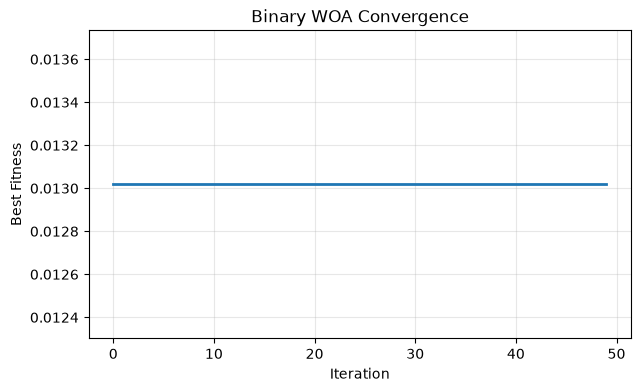

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(convergence_curve, linewidth=2)

plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Binary WOA Convergence")

plt.grid(alpha=0.3)
plt.show()

## 5. Evaluate the best feature subset

Using the exact same `evaluate_subset()` function as the baseline notebook.

In [7]:
best_mask = best_position.astype(int)

selected_features = [
    f for f, m in zip(feature_names, best_mask)
    if m == 1
]

print(f"BWOA selected {best_mask.sum()} / {n_features} features:")
print(selected_features)

results = evaluate_subset(
    best_mask,
    X_train,
    X_test,
    y_train,
    y_test,
    classifier="svm"
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "n_features"]:
    print(f"{metric}: {results[metric]}")

BWOA selected 13 / 30 features:
['mean texture', 'mean smoothness', 'mean compactness', 'mean concave points', 'texture error', 'compactness error', 'concave points error', 'symmetry error', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst fractal dimension']
accuracy: 0.9912280701754386
precision: 0.9863013698630136
recall: 1.0
f1: 0.993103448275862
roc_auc: 0.9970238095238095
n_features: 13


## 6. Save results

Saved to `../results/woa_results.csv` and
`../results/woa_convergence.npy` for `07_Comparison.ipynb`.

In [8]:
import os
os.makedirs("../results", exist_ok=True)

results_df = pd.DataFrame([{
    "Algorithm": "WOA",
    "Accuracy": results["accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1": results["f1"],
    "ROC_AUC": results["roc_auc"],
    "Features": results["n_features"],
    "Runtime": runtime,
}])

results_df.to_csv("../results/woa_results.csv", index=False)
np.save("../results/woa_convergence.npy", np.array(convergence_curve))
np.save("../results/woa_mask.npy", best_mask)

results_df

,Algorithm,Accuracy,Precision,Recall,F1,ROC_AUC,Features,Runtime
0,WOA,0.991228,0.986301,1.0,0.993103,0.997024,13,40.577351


## Next step

Run the remaining optimizer notebooks (any not yet run), then open
`07_Comparison.ipynb` to compare WOA against the baseline and the other
metaheuristics side by side.